In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
import matplotlib.lines as mlines

In [2]:
models_w_training = ["dinomaly","efficientad","draem"]
models = models_w_training + ["winclip","patchcore","padim"]
categories = ["bottle","capsule","hazelnut","metal_nut","pill","screw","toothbrush","transistor","zipper","cable","carpet","grid","leather","tile","wood"]

df_training = pd.concat([pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/resultats_finaux_mvtec_ad/{model}/{model}/{category}/metrics.csv").assign(model=model) 
                                    for model in models_w_training]).assign(category=category)
                         for category in categories])

df_training = df_training.groupby(["epoch","category","model"], as_index=False).first()

df_results= pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/resultats_finaux_mvtec_ad/{model}/mvtec_results.csv") for model in models])

In [3]:
categories_jeans = ["jeans_troues","jeans_troues_detoures"]
df_training_jeans = pd.concat([pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/results_dataset_jeans/{model}/{category}/metrics.csv").assign(model=model) 
                                    for model in models_w_training]).assign(category=category)
                         for category in categories_jeans])

df_training_jeans = df_training_jeans.groupby(["epoch","category","model"], as_index=False).first()

df_results_jeans= pd.concat([pd.read_csv(f"/home/vince/ENSTA/4A/projet/anomalib/results/results_dataset_jeans/results_benchmark_{category}.csv").assign(category=category)  for category in categories_jeans])

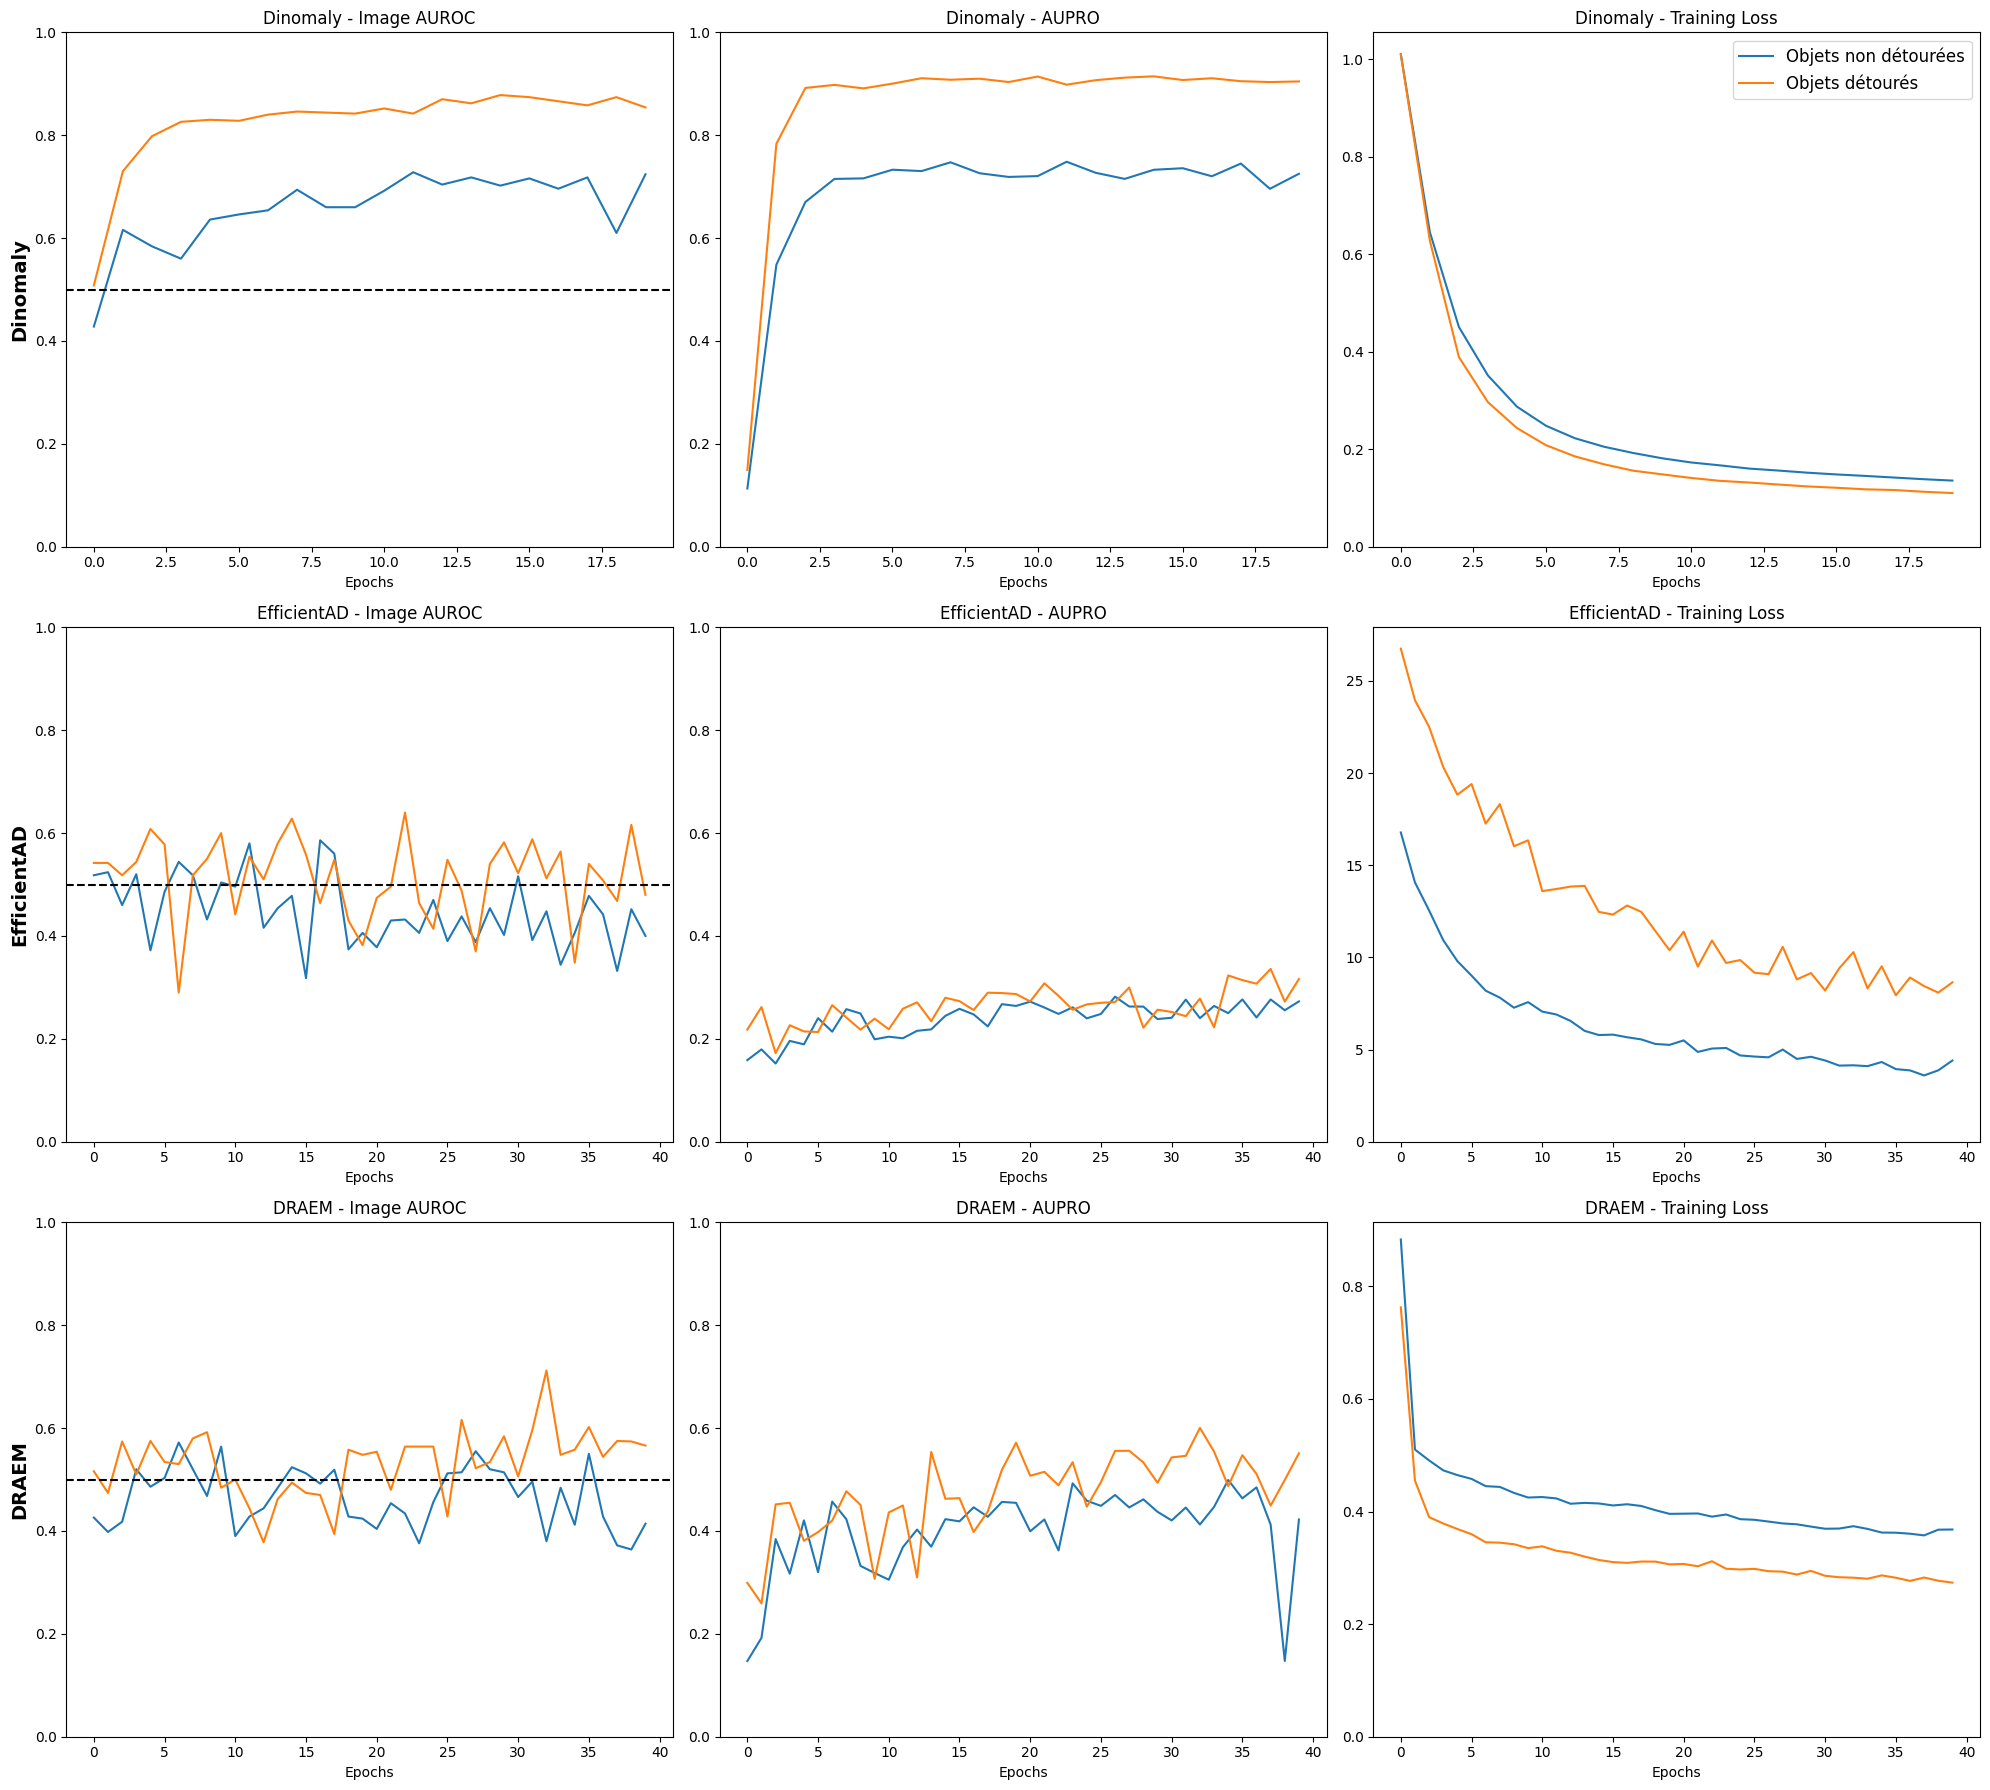

In [6]:
df = df_training_jeans.copy()

model_map = {"dinomaly": "Dinomaly", "efficientad": "EfficientAD", "draem": "DRAEM"}
category_map = {"jeans_troues": "Objets non détourées", "jeans_troues_detoures": "Objets détourés"}

fig, axes = plt.subplots(len(models_w_training), 3, figsize=(20, 6 * len(models_w_training)))

if len(models_w_training) == 1:
    axes = axes.reshape(1, 3)

for i, model_name in enumerate(models_w_training):
    df_model = df[df.model == model_name]
    
    for name, group in df_model.groupby("category"):
        clean_name = category_map.get(name, name) # Récupère le nom propre ou garde l'original
        group.plot(x="epoch", y="AUROC", ax=axes[i, 0], label=clean_name, legend=False)
        group.plot(x="epoch", y="AUPRO", ax=axes[i, 1], label=clean_name, legend=False)
        group.plot(x="epoch", y="train_loss_epoch", ax=axes[i, 2], label=clean_name, legend=False)

    display_name = model_map.get(model_name.lower(), model_name)
    
    axes[i, 0].set_ylabel(display_name, fontsize=14, fontweight='bold')
    axes[i, 0].set_title(f"{display_name} - Image AUROC")
    axes[i, 1].set_title(f"{display_name} - AUPRO")
    axes[i, 2].set_title(f"{display_name} - Training Loss")
    axes[i, 0].axhline(y=0.5, color='black', linestyle='--')

    for j in range(3):
        axes[i, j].set_xlabel("Epochs")
    for j in range(2):
        axes[i, j].set_ylim(0,1)
    axes[i, 2].set_ylim(0)

handles, labels = axes[0, 0].get_legend_handles_labels()

axes[0, 2].legend(handles, labels, loc='upper right', fontsize='large', frameon=True)

plt.tight_layout()
# plt.savefig("/home/vince/ENSTA/4A/projet/anomalib/results/figures/training_curbs_mvtec.png")

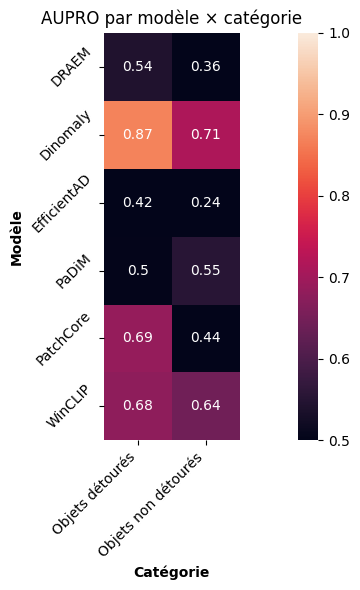

In [ ]:
model_map = {"dinomaly": "Dinomaly", "efficientad": "EfficientAD", "draem": "DRAEM","patchcore":"PatchCore","winclip":"WinCLIP","padim":"PaDiM"}
category_map = {"jeans_troues": "Objets non détourés", "jeans_troues_detoures": "Objets détourés"}

df = df_results.copy()
df = df[["AUPRO", "model", "category"]]

df['model'] = df['model'].str.lower().map(model_map).fillna(df['model'])
df['category'] = df['category'].map(category_map).fillna(df['category'])

df_pivot = df.pivot(columns="category", index="model", values="AUPRO")

plt.figure(figsize=(12, 6))
plt.title("AUPRO par modèle × catégorie")

sns.heatmap(df_pivot, annot=True, square=True, vmin=0.5, vmax=1.0)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')

plt.xlabel("Catégorie", fontweight='bold')
plt.ylabel("Modèle", fontweight='bold')

plt.tight_layout()
# plt.savefig("/home/vince/ENSTA/4A/projet/anomalib/results/figures/AUPRO_mvtec.png",bbox_inches='tight')

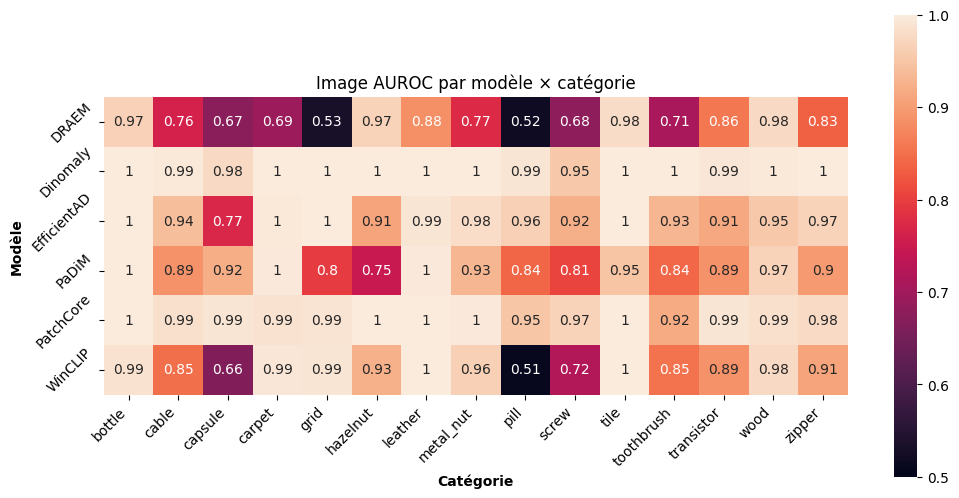

In [6]:
model_map = {"dinomaly": "Dinomaly", "efficientad": "EfficientAD", "draem": "DRAEM","patchcore":"PatchCore","winclip":"WinCLIP","padim":"PaDiM"}
category_map = {"jeans_troues": "Objets non détourés", "jeans_troues_detoures": "Objets détourés"}

df = df_results.copy()
df = df[["image_AUROC","model","category"]]

df['model'] = df['model'].str.lower().map(model_map).fillna(df['model'])
df['category'] = df['category'].map(category_map).fillna(df['category'])

df = df.pivot(columns="category", index="model", values="image_AUROC")
plt.figure(figsize=(12,6))
plt.title("Image AUROC par modèle × catégorie")
sns.heatmap(df,annot=True,square=True, vmin=0.5, vmax=1.0)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')

plt.xlabel("Catégorie", fontweight='bold')
plt.ylabel("Modèle", fontweight='bold')

plt.savefig("/home/vince/ENSTA/4A/projet/anomalib/results/figures/img_AUROC_mvtec.png",bbox_inches='tight')

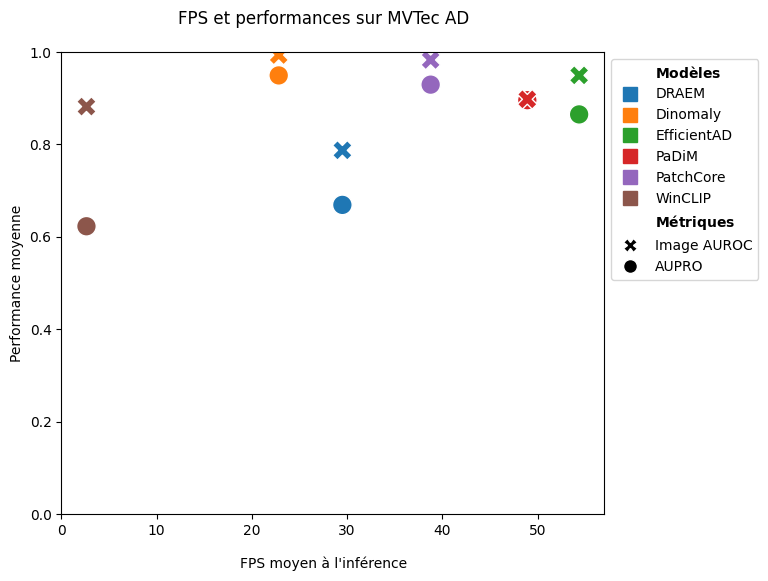

In [5]:
model_map = {"dinomaly": "Dinomaly", "efficientad": "EfficientAD", "draem": "DRAEM","patchcore":"PatchCore","winclip":"WinCLIP","padim":"PaDiM"}
df = df_results.copy()


df['model'] = df['model'].str.lower().map(model_map).fillna(df['model'])

df_avg = df.groupby("model")[['inference_fps', 'image_AUROC','AUPRO']].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(wspace=0.08)



sns.scatterplot(data=df_avg, x='inference_fps', y='AUPRO', 
                hue='model', marker='o', s=200, ax=ax, legend=False,
                edgecolor='white', linewidth=1)

sns.scatterplot(data=df_avg, x='inference_fps', y='image_AUROC', 
                hue='model', marker='X', s=200, ax=ax, legend=False,
                edgecolor='white', linewidth=1)

palette = sns.color_palette(n_colors=len(df_avg['model'].unique()))
model_names = df_avg['model'].unique()

model_legend = [mlines.Line2D([], [], color='none', label=r'$\bf{Modèles}$')]
for name, color in zip(model_names, palette):
    model_legend.append(mlines.Line2D([], [], color=color, marker='s', linestyle='None', 
                                    markersize=10, label=name))

metric_legend = [mlines.Line2D([], [], color='none', label=r'$\bf{Métriques}$')]
metric_legend.append(mlines.Line2D([], [], color='black', marker='X', linestyle='None', 
                                   markeredgecolor='white', markeredgewidth=1,
                                   markersize=10, label='Image AUROC'))
metric_legend.append(mlines.Line2D([], [], color='black', marker='o', linestyle='None', 
                                   markeredgecolor='white', markeredgewidth=1,
                                   markersize=10, label='AUPRO'))

ax.set_ylabel("Performance moyenne")
ax.legend(bbox_to_anchor=(1, 1), handles=model_legend + metric_legend)
fig.text(0.5, 0.02, "FPS moyen à l'inférence", ha='center')
plt.ylim(0, 1)
plt.xlim(0)
plt.xlabel(None)
plt.suptitle("FPS et performances sur MVTec AD", y=0.95)
plt.savefig("/home/vince/ENSTA/4A/projet/anomalib/results/figures/performance_inference_fps_mvtec.png", bbox_inches='tight')

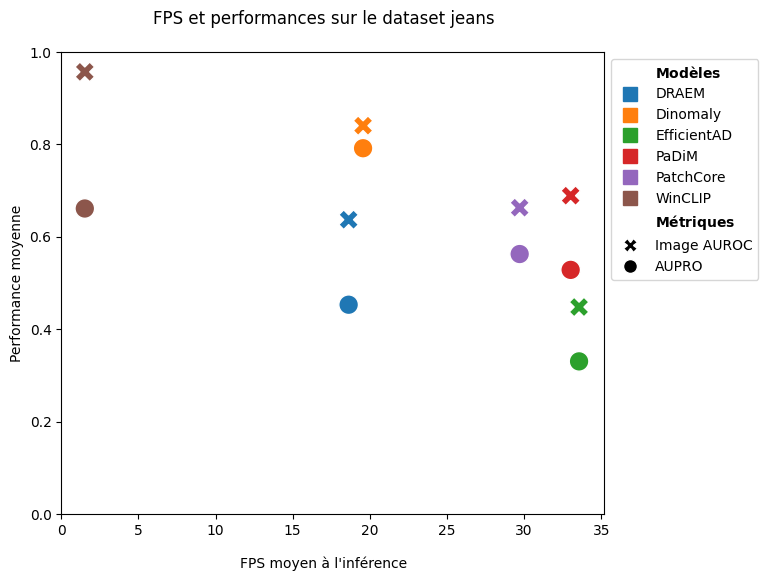

In [4]:
model_map = {"dinomaly": "Dinomaly", "efficientad": "EfficientAD", "draem": "DRAEM","patchcore":"PatchCore","winclip":"WinCLIP","padim":"PaDiM"}
df = df_results_jeans.copy()


df['model'] = df['model'].str.lower().map(model_map).fillna(df['model'])

df_avg = df.groupby("model")[['inference_fps', 'image_AUROC','AUPRO']].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(wspace=0.08)



sns.scatterplot(data=df_avg, x='inference_fps', y='AUPRO', 
                hue='model', marker='o', s=200, ax=ax, legend=False,
                edgecolor='white', linewidth=1)

sns.scatterplot(data=df_avg, x='inference_fps', y='image_AUROC', 
                hue='model', marker='X', s=200, ax=ax, legend=False,
                edgecolor='white', linewidth=1)

palette = sns.color_palette(n_colors=len(df_avg['model'].unique()))
model_names = df_avg['model'].unique()

model_legend = [mlines.Line2D([], [], color='none', label=r'$\bf{Modèles}$')]
for name, color in zip(model_names, palette):
    model_legend.append(mlines.Line2D([], [], color=color, marker='s', linestyle='None', 
                                    markersize=10, label=name))

metric_legend = [mlines.Line2D([], [], color='none', label=r'$\bf{Métriques}$')]
metric_legend.append(mlines.Line2D([], [], color='black', marker='X', linestyle='None', 
                                   markeredgecolor='white', markeredgewidth=1,
                                   markersize=10, label='Image AUROC'))
metric_legend.append(mlines.Line2D([], [], color='black', marker='o', linestyle='None', 
                                   markeredgecolor='white', markeredgewidth=1,
                                   markersize=10, label='AUPRO'))

ax.set_ylabel("Performance moyenne")
ax.legend(bbox_to_anchor=(1, 1), handles=model_legend + metric_legend)
fig.text(0.5, 0.02, "FPS moyen à l'inférence", ha='center')
plt.ylim(0, 1)
plt.xlim(0)
plt.xlabel(None)
plt.suptitle("FPS et performances sur le dataset jeans", y=0.95)
plt.savefig("/home/vince/ENSTA/4A/projet/anomalib/results/figures/performance_inference_fps_jeans.png", bbox_inches='tight')

Text(0.5, 1.0, "Temps d'entrainement moyen par modèle × catégorie")

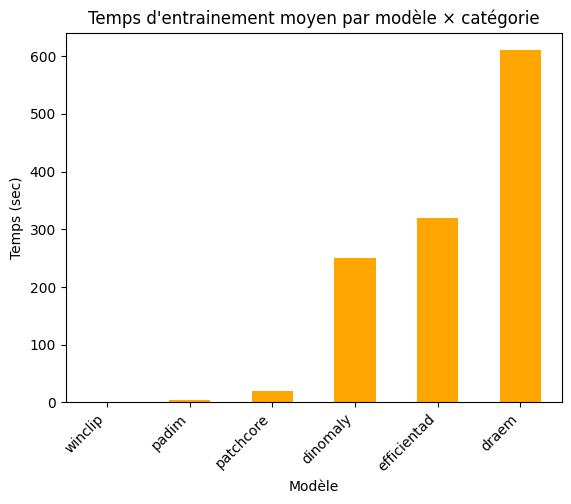

In [33]:
df = df_results_jeans.copy()
df = df[["model","train_time_sec"]]
df.groupby("model").mean().sort_values("train_time_sec").plot(kind="bar", color="orange",legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Modèle")
plt.ylabel("Temps (sec)")
plt.title("Temps d'entrainement moyen par modèle × catégorie")


Text(0.5, 1.0, "Temps d'inférence moyen par modèle × catégorie")

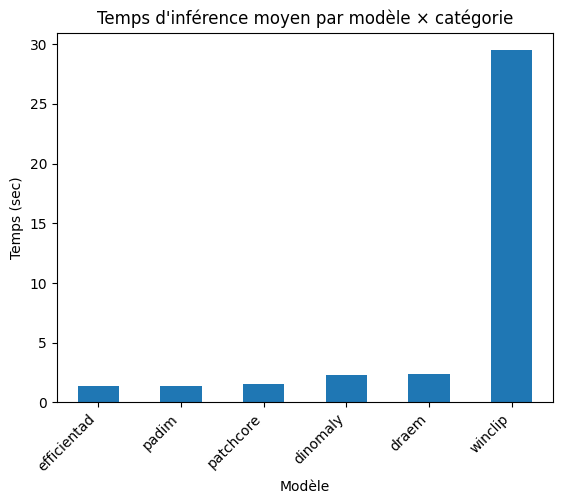

In [149]:
df = df_results_jeans.copy()
df = df[["model","inference_time_sec"]]
df.groupby("model").mean().sort_values("inference_time_sec").plot(kind="bar", legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Modèle")
plt.ylabel("Temps (sec)")
plt.title("Temps d'inférence moyen par modèle × catégorie")


Text(0.5, 0, 'Classes')

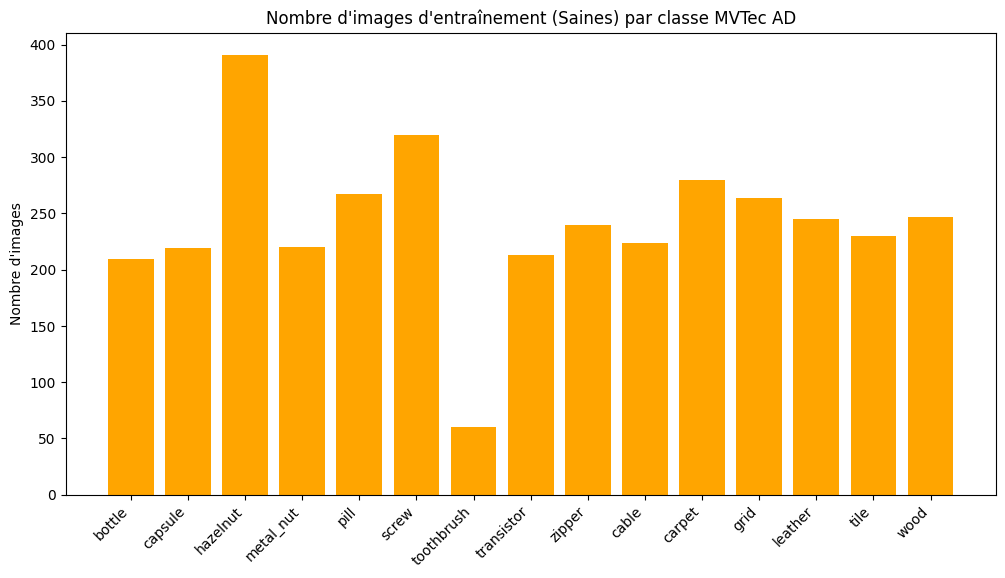

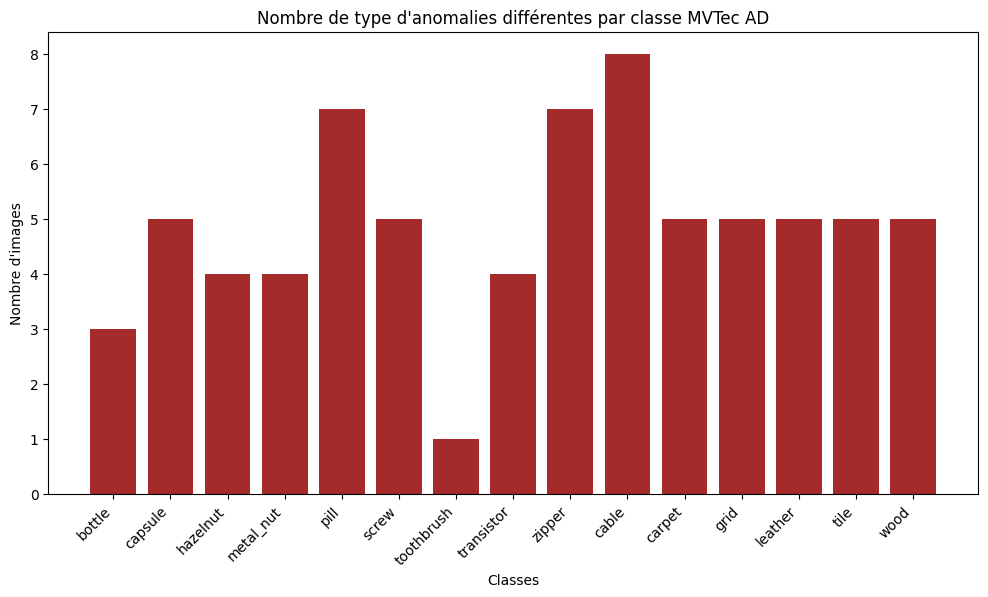

In [52]:
mvtec_train_counts = {
    "bottle": 209, "capsule": 219, "hazelnut": 391,
    "metal_nut": 220, "pill": 267, "screw": 320, "toothbrush": 60,
    "transistor": 213, "zipper": 240, "cable": 224, "carpet": 280, "grid": 264,
    "leather": 245, "tile": 230, "wood": 247
}

mvtec_anomaly_types_counts = {
    "bottle": 3,      # broken_large, broken_small, contamination
    "capsule": 5,     # crack, faulty_imprint, poke, scratch, squeeze
    "hazelnut": 4,    # crack, cut, hole, print
    "metal_nut": 4,   # bent, color, flip, scratch
    "pill": 7,        # combined, contamination, crack, faulty_imprint, pill_type, scratch, SIMULATED
    "screw": 5,       # manipulated_front, scratch_head, scratch_neck, thread_side, thread_top
    "toothbrush": 1,  # defective
    "transistor": 4,  # bent_lead, cut_lead, damaged_case, misplaced
    "zipper": 7,      # broken_teeth, combined, fabric_interior, fabric_border, rough, squeezed, twisted
    "cable": 8,       # bent, cable_swap, combined, cut, missing_cable, missing_wire, poke, twisted
    "carpet": 5,      # color, cut, hole, metal_contamination, thread
    "grid": 5,        # bent, broken, glue, metal_contamination, thread
    "leather": 5,     # color, cut, fold, glue, poke
    "tile": 5,        # crack, glue, oil, rough, scratch
    "wood": 5         # combined, hole, liquid, scratch, color
}

categories = list(mvtec_train_counts.keys())
counts = list(mvtec_train_counts.values())
anomaly_types_counts = list(mvtec_anomaly_types_counts.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, counts,color="orange")
plt.xticks(rotation=45, ha='right')
plt.title("Nombre d'images d'entraînement (Saines) par classe MVTec AD")
plt.ylabel("Nombre d'images")

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, anomaly_types_counts,color="brown")
plt.xticks(rotation=45, ha='right')
plt.title("Nombre de type d'anomalies différentes par classe MVTec AD")
plt.ylabel("Nombre d'images")
plt.xlabel("Classes")

# Analyse qualitative

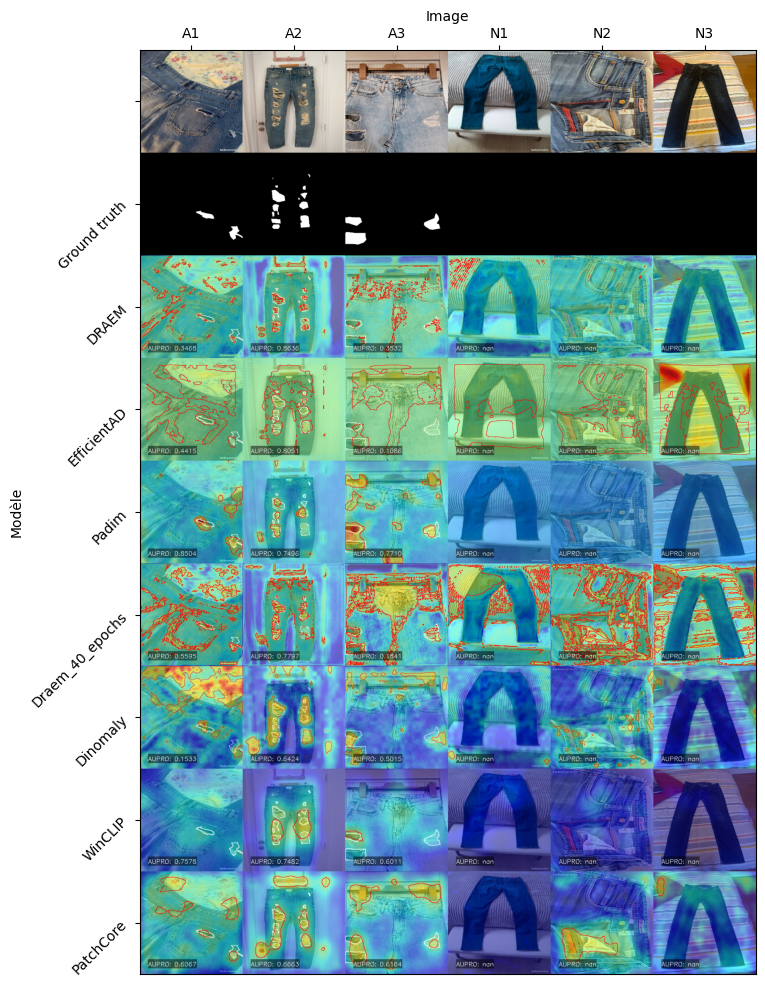

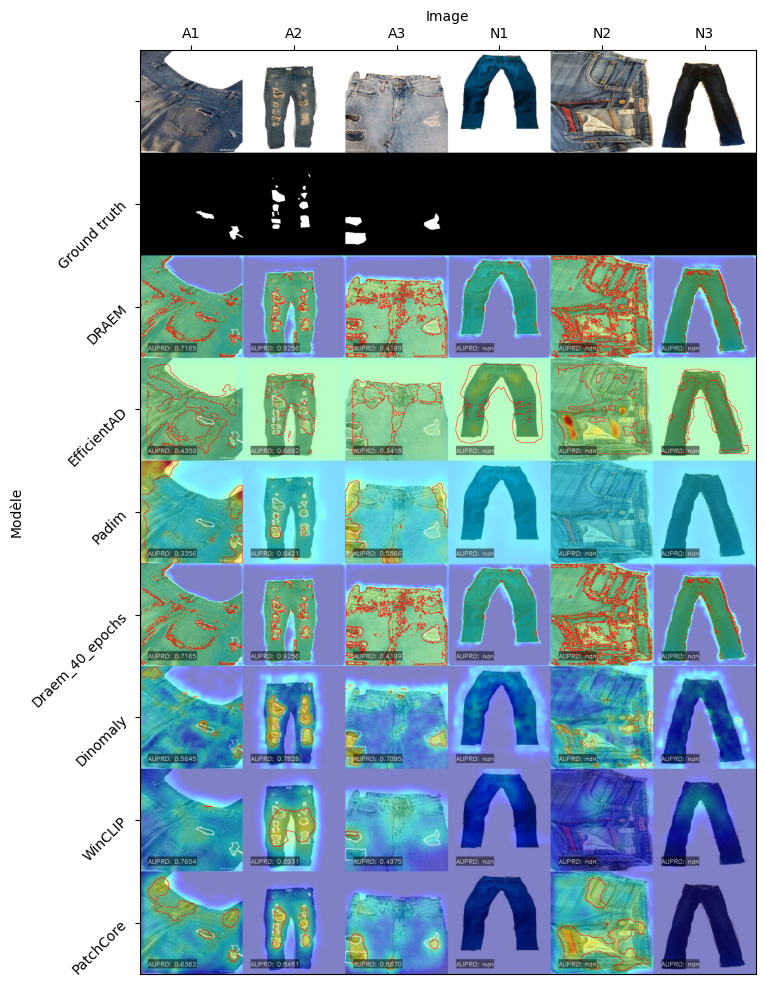

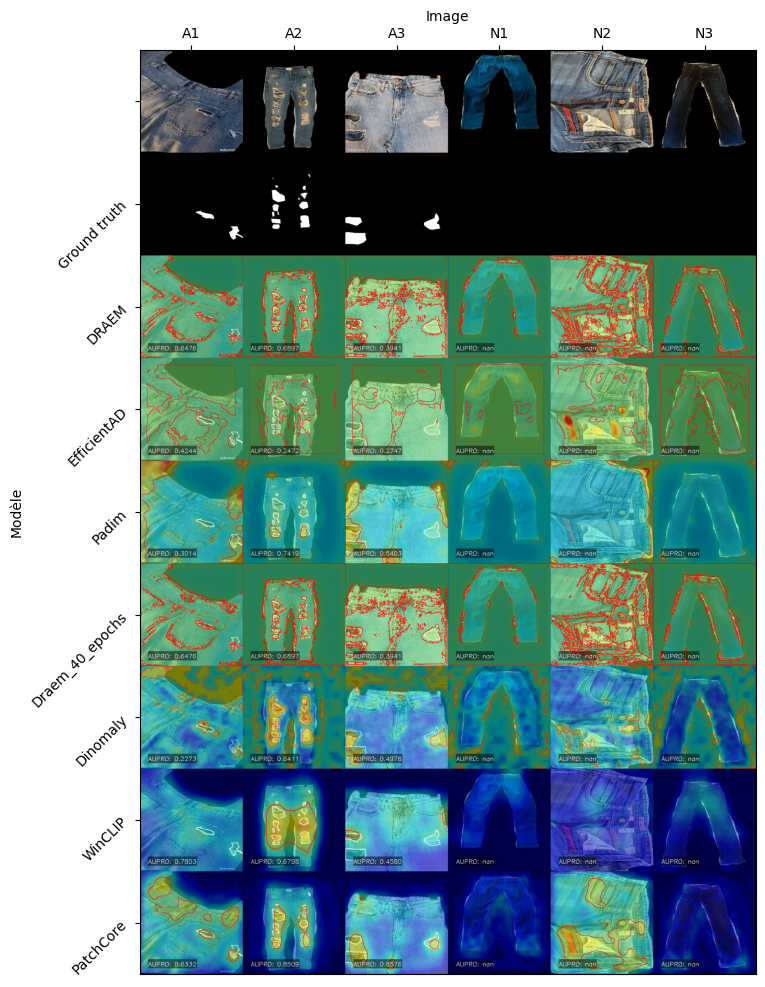

In [11]:
PATH = "/home/vince/ENSTA/4A/projet/anomalib/results/images_inference_analyse_quali"
PATH_RAW_IMGS = "/home/vince/ENSTA/4A/projet/scraping/images_inference_analyse_quali"

imgs_selection=[1,3,6,9,5,7]
raw_imgs_selection=[108,19,5,755,433,542]
descriptions = {
    "result_1.png": "A1",
    "result_3.png": "A2",
    "result_6.png": "A3",
    "result_9.png": "N1",
    "result_5.png": "N2",
    "result_7.png": "N3"
}
model_map = {"Dinomaly": "Dinomaly", "EfficientAd": "EfficientAD", "Draem": "DRAEM","Patchcore":"PatchCore","WinClip":"WinCLIP"}

for category in ["jeans_troues", "jeans_troues_detoures","jeans_troues_detoures_fond_noir"]:
    table = []
    model_names = []
    
    models = [m for m in os.listdir(PATH) if os.path.isdir(os.path.join(PATH, m))]
    
    for model in ["","Ground truth"] + models:
        if model == "":

            row_paths = [os.path.join(PATH_RAW_IMGS,category,f"image_{i}.jpg") for i in raw_imgs_selection]
            imgs = [cv2.cvtColor(cv2.resize(cv2.imread(path), (256, 256)), cv2.COLOR_BGR2RGB) for path in row_paths]
        elif model == "Ground truth":
            row_paths = [os.path.join(PATH_RAW_IMGS,"masks",f"image_{i}.png") for i in raw_imgs_selection]
            imgs = [cv2.cvtColor(cv2.resize(cv2.imread(path), (256, 256)), cv2.COLOR_BGR2RGB) for path in row_paths]

        else:
            p = os.path.join(PATH, model, category)
            row_paths = [os.path.join(p, f"result_{j}.png") for j in imgs_selection]
            imgs = [cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB) for path in row_paths]
                
        
        row = cv2.hconcat(imgs)
        table.append(row)
        model_names.append(model)

    figure = cv2.vconcat(table)
    
    # --- Calcul des positions ---
    h_row = table[0].shape[0]   # Hauteur d'une ligne
    w_img = imgs[0].shape[1]    # Largeur d'une image individuelle
    
    yticks_pos = [i * h_row + h_row // 2 for i in range(len(model_names))]
    xticks_pos = [i * w_img + w_img // 2 for i in range(len(imgs_selection))]
    xtick_labels = [descriptions.get(f"result_{i}.png",f"result_{i}.png") for i in imgs_selection]

    # --- Affichage ---
    plt.figure(figsize=(25, 12))
    ax = plt.gca()
    plt.imshow(figure)
    
    plt.xticks(xticks_pos, xtick_labels)
    plt.xlabel("Image")
    ax.xaxis.tick_top() # Déplace les labels X en haut
    ax.xaxis.set_label_position('top')
    
    plt.yticks(yticks_pos, [model_map.get(model_name,model_name) for model_name in model_names],rotation=45)
    plt.ylabel("Modèle")

    # plt.savefig(f"/home/vince/ENSTA/4A/projet/anomalib/results/figures/analyse_quali_{category}.png",bbox_inches='tight')

